## Homework 6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score

### 1. Load, encode, and split off the test set

In [ ]:
df = pd.read_excel('../data_manufacturing.xlsx')
y = df['Dissolution'].values
X_df = df.drop(columns=['Dissolution'])

# One-Hot encode the categorical columns
string_col_indices = [i for i, c in enumerate(X_df.columns)
                      if X_df[c].dtype == object or str(X_df[c].dtype) == 'str']
pre = ColumnTransformer(
    [('ohe', OneHotEncoder(drop='first', sparse_output=False), string_col_indices)],
    remainder='passthrough')
X = pre.fit_transform(X_df)
feature_names = [n.replace('ohe__', '').replace('remainder__', '')
                 for n in pre.get_feature_names_out()]

# Split with a fixed random state for reproducibility and a test size of 10%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42)
print(f'train: {X_train.shape[0]} samples,  test: {X_test.shape[0]} samples')

train: 81 samples,  test: 9 samples


### 2. 5-fold CV over alpha

In [ ]:
alphas = np.logspace(-3, 1, 50)   # grid of penalty values

def cv_curves(X_tr, y_tr, alphas, seed):
    """Return mean train- and validation-RMSE across 5 folds for each alpha."""
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    tr_rmse = np.zeros((len(alphas), 5))
    va_rmse = np.zeros((len(alphas), 5))
    for j, (ti, vi) in enumerate(kf.split(X_tr)):
        for a_i, a in enumerate(alphas):
            # scaler is fit on the training fold only, so we get no leakage
            pipe = Pipeline([('sc', StandardScaler()),
                             ('ls', Lasso(alpha=a, max_iter=100000))])
            pipe.fit(X_tr[ti], y_tr[ti])
            tr_rmse[a_i, j] = root_mean_squared_error(y_tr[ti], pipe.predict(X_tr[ti]))
            va_rmse[a_i, j] = root_mean_squared_error(y_tr[vi], pipe.predict(X_tr[vi]))
    return tr_rmse.mean(axis=1), va_rmse.mean(axis=1)

train_rmse, val_rmse = cv_curves(X_train, y_train, alphas, seed=0)
best = np.argmin(val_rmse)
alpha_opt = alphas[best]
print(f'Optimal alpha = {alpha_opt:.5f}  (log10 = {np.log10(alpha_opt):.2f})')
print(f'Mean validation RMSE at optimum = {val_rmse[best]:.4f}')

Optimal alpha = 0.09103  (log10 = -1.04)
Mean validation RMSE at optimum = 1.3883


### 3. Train vs. validation RMSE over alpha

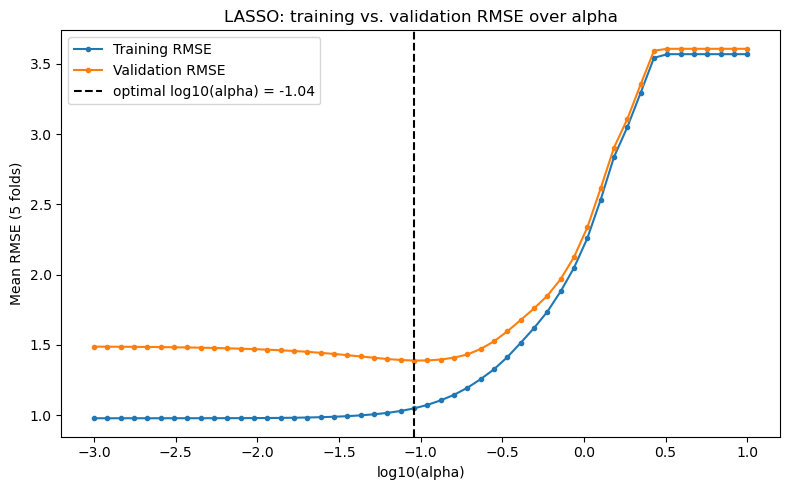

In [ ]:
# Plot the CV curves for training and validation RMSE over the alpha grid
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.log10(alphas), train_rmse, label='Training RMSE', marker='.')
ax.plot(np.log10(alphas), val_rmse, label='Validation RMSE', marker='.')
ax.axvline(np.log10(alpha_opt), color='k', linestyle='--',
           label=f'optimal log10(alpha) = {np.log10(alpha_opt):.2f}')
ax.set_xlabel('log10(alpha)')
ax.set_ylabel('Mean RMSE (5 folds)')
ax.set_title('LASSO: training vs. validation RMSE over alpha')
ax.legend(); plt.tight_layout(); plt.show()

The two curves show the classic bias–variance trade-off:
- Small alpha: weak penalty, many parameters. Training RMSE is lowest, but validation RMSE is higher, that means the model overfits.
- Large alpha: strong penalty, coefficients shrink to zero. Both RMSEs rise, that means the model underfits.
- The gap between training and validation RMSE is the overfitting gap; the optimal alpha sits near where validation RMSE is minimal.

### 4. Refit at optimal alpha and evaluation

In [ ]:
final = Pipeline([('sc', StandardScaler()),
                  ('ls', Lasso(alpha=alpha_opt, max_iter=100000))])
final.fit(X_train, y_train)   # refit on the training set at chosen alpha value

# Evaluate on the independent test set
y_test_hat = final.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_hat)
test_r2   = r2_score(y_test, y_test_hat)
n_nonzero = np.sum(final.named_steps['ls'].coef_ != 0)

print(f'Independent Test RMSE = {test_rmse:.4f}')
print(f'Independent Test R^2  = {test_r2:.4f}')
print(f'Non-zero coefficients : {n_nonzero} / {len(feature_names)}')

Independent Test RMSE = 1.0781
Independent Test R^2  = 0.8932
Non-zero coefficients : 14 / 19


### Final Model

In [13]:
records = []

# We repeat the process using 10 different random seeds for the CV splits
for seed in range(10):
    tr_m, va_m = cv_curves(X_train, y_train, alphas, seed=seed)
    b = np.argmin(va_m)
    a_opt_s = alphas[b]
    # refit and test for this seed's chosen alpha
    fm = Pipeline([('sc', StandardScaler()),
                   ('ls', Lasso(alpha=a_opt_s, max_iter=100000))]).fit(X_train, y_train)
    t_rmse = root_mean_squared_error(y_test, fm.predict(X_test))
    records.append({'seed': seed, 'alpha': a_opt_s,
                    'val_rmse': va_m[b], 'test_rmse': t_rmse})

res = pd.DataFrame(records)
print(res.to_string(index=False))
print('\nDistribution across seeds:')
print(res[['alpha', 'val_rmse', 'test_rmse']].agg(['mean', 'std', 'min', 'max']))

 seed    alpha  val_rmse  test_rmse
    0 0.091030  1.388321   1.078130
    1 0.062506  1.278227   1.006212
    2 0.051795  1.346286   0.992487
    3 0.042919  1.457939   0.981662
    4 0.062506  1.371807   1.006212
    5 0.091030  1.291086   1.078130
    6 0.042919  1.349183   0.981662
    7 0.091030  1.376168   1.078130
    8 0.091030  1.448567   1.078130
    9 0.132571  1.419090   1.202158

Distribution across seeds:
         alpha  val_rmse  test_rmse
mean  0.075933  1.372667   1.048291
std   0.028368  0.059877   0.068937
min   0.042919  1.278227   0.981662
max   0.132571  1.457939   1.202158


### Distribution Plots

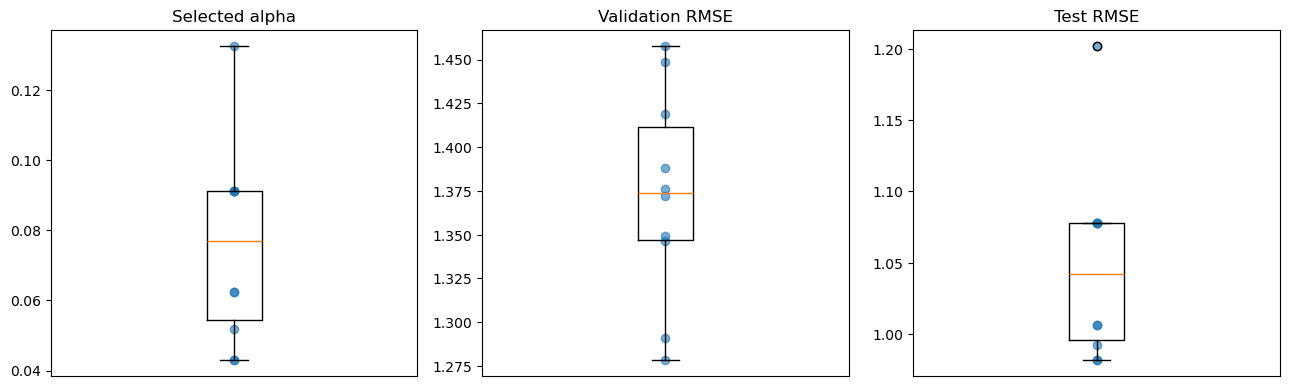

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
                          ['alpha', 'val_rmse', 'test_rmse'],
                          ['Selected alpha', 'Validation RMSE', 'Test RMSE']):
    ax.boxplot(res[col]); ax.scatter(np.ones(len(res)), res[col], alpha=0.6)
    ax.set_title(title); ax.set_xticks([])
plt.tight_layout(); plt.show()

### 6. Discussion

#### Results vs. Exercise 6
| | Exercise 6 | Exercise 7 |
|---|---|---|
| Tuning | `LassoCV` on all data | manual 5-fold CV with 0.1 split |
| Selected $\alpha$ | ≈ 0.048 | ≈ 0.09 (seed 0); 0.04–0.13 across seeds |
| RMSE reported | 1.03 | ≈ 1.08 |
| R² | 0.92 (training) | ≈ 0.89 (test) |

The main difference is what the numbers actually mean. Exercise 6 reported RMSE on the same data used to fit, which is optimistic. Exercise 7 reports RMSE on data the model never saw during tuning or fitting, which is the most honest generalization estimate. The test RMSE (≈ 1.08) being only slightly worse than the training RMSE (≈ 1.03) is reassuring, meaning the LASSO model generalizes well and is not badly overfitting.

#### Is the hyperparameter stable?
Across the 10 fold seeds, the selected $\alpha$ ranged roughly 0.04–0.13 (mean ≈ 0.076, std ≈ 0.027, resulting in a coefficient of variation around 35 %). So the exact $\alpha$ is moderatly unstable. This is expected with only 81 training samples, because the validation folds are tiny (~16 points each), so the validation RMSE curve is flat and noisy near its minimum, and small changes move the argmin.

But this instability barely matters in practice:
- The test RMSE varied only ≈ 0.98–1.20 (std ≈ 0.065). Because the validation curve is flat near the optimum, different $\alpha$ values in that range give almost the same predictive performance.
- The selected $\alpha$ always stays in the same order of magnitude (~0.05–0.1), so the qualitative model is robust.

We can conclude that the precise optimal $\alpha$ is sensitive to the fold split and should not be overinterpreted, but the resulting model performance is stable. With such a small dataset, reporting a range of reasonable $\alpha$ (or using repeated/nested CV) is more honest than quoting a single value.